# PCA of simulated NMC spectra

Read every `.dat` spectrum in `datasets/NMC_simulated`, retain **10 principal components**, and map their scores onto the measurement coordinates in a **3-column** subplot layout.

Filenames follow `name_x_theta1_y_theta2[_suffix].dat`. The extracted x and y values are treated as **nanometers**; the angles are not coordinates. Spectra contain three header lines followed by channel/count pairs. Missing channels (including the tails of shorter spectra) are padded with zero counts on a shared channel axis. PCA centers the counts but does not normalize each spectrum, so intensity differences contribute to the result.

Requires NumPy, Matplotlib, and scikit-learn. If needed, run `%pip install numpy matplotlib scikit-learn` in a notebook cell.


In [5]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Support launching from either the repository root or examples/.
candidates = [Path.cwd() / "datasets" / "NMC_simulated",
              Path.cwd() / "examples" / "datasets" / "NMC_simulated"]
data_dir = next((p for p in candidates if p.is_dir()), None)
if data_dir is None:
    raise FileNotFoundError("Run this notebook from the repository root or examples/.")
files = sorted(data_dir.glob("*.dat"))
if not files:
    raise FileNotFoundError(f"No .dat spectra found in {data_dir}")

number = r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?"
filename_pattern = re.compile(
    rf"^.+?_(?P<x>{number})_(?P<theta1>{number})_"
    rf"(?P<y>{number})_(?P<theta2>{number})(?:_.*)?$"
)
coordinates = []
spectra = []
for path in files:
    match = filename_pattern.fullmatch(path.stem)
    if match is None:
        raise ValueError(f"Cannot extract coordinates from {path.name}")
    coordinates.append((float(match['x']), float(match['y'])))
    data = np.loadtxt(path, skiprows=3, ndmin=2)
    if data.shape[0] == 0 or data.shape[1] != 2 or not np.isfinite(data).all():
        raise ValueError(f"Expected finite channel/count pairs in {path.name}")
    channels, counts = data.T
    if (channels < 0).any() or not np.equal(channels, np.floor(channels)).all():
        raise ValueError(f"Expected nonnegative integer channels in {path.name}")
    channels = channels.astype(np.int64)
    if np.unique(channels).size != channels.size:
        raise ValueError(f"Duplicate channels in {path.name}")
    spectra.append((channels, counts))

coordinates_nm = np.asarray(coordinates)
channel_axis = np.arange(max(channels.max() for channels, _ in spectra) + 1)
X = np.zeros((len(spectra), len(channel_axis)), dtype=np.float64)
for row, (channels, counts) in enumerate(spectra):
    X[row, channels] = counts
lengths = np.array([len(channels) for channels, _ in spectra])
print(f"Loaded {len(files):,} spectra; lengths: {lengths.min()}–{lengths.max()} channels")
print(f"Zero-padded matrix shape: {X.shape}")


Loaded 10,000 spectra; lengths: 1667–5867 channels
Zero-padded matrix shape: (10000, 5867)


In [6]:
n_components = 10
if min(X.shape) < n_components:
    raise ValueError("At least 10 spectra and 10 channels are required for 10-component PCA.")
if not np.any(np.var(X, axis=0) > 0):
    raise ValueError("PCA requires variation between spectra.")

# Randomized SVD keeps the calculation practical for the full dataset.
pca = PCA(n_components=n_components, svd_solver="randomized", random_state=0)
scores = pca.fit_transform(X)
for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC {i:2d}: {ratio:.2%} explained variance")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2%}")


PC  1: 65.58% explained variance
PC  2: 31.17% explained variance
PC  3: 1.76% explained variance
PC  4: 0.83% explained variance
PC  5: 0.39% explained variance
PC  6: 0.18% explained variance
PC  7: 0.02% explained variance
PC  8: 0.02% explained variance
PC  9: 0.01% explained variance
PC 10: 0.00% explained variance
Total explained variance: 99.96%


## Spatial component scores

Each panel displays one column of `scores`, not the spectral loading vector. Missing spatial points remain blank. If multiple spectra share a coordinate, their scores are averaged for display. Each panel has its own symmetric color scale around zero; PCA component signs are arbitrary.


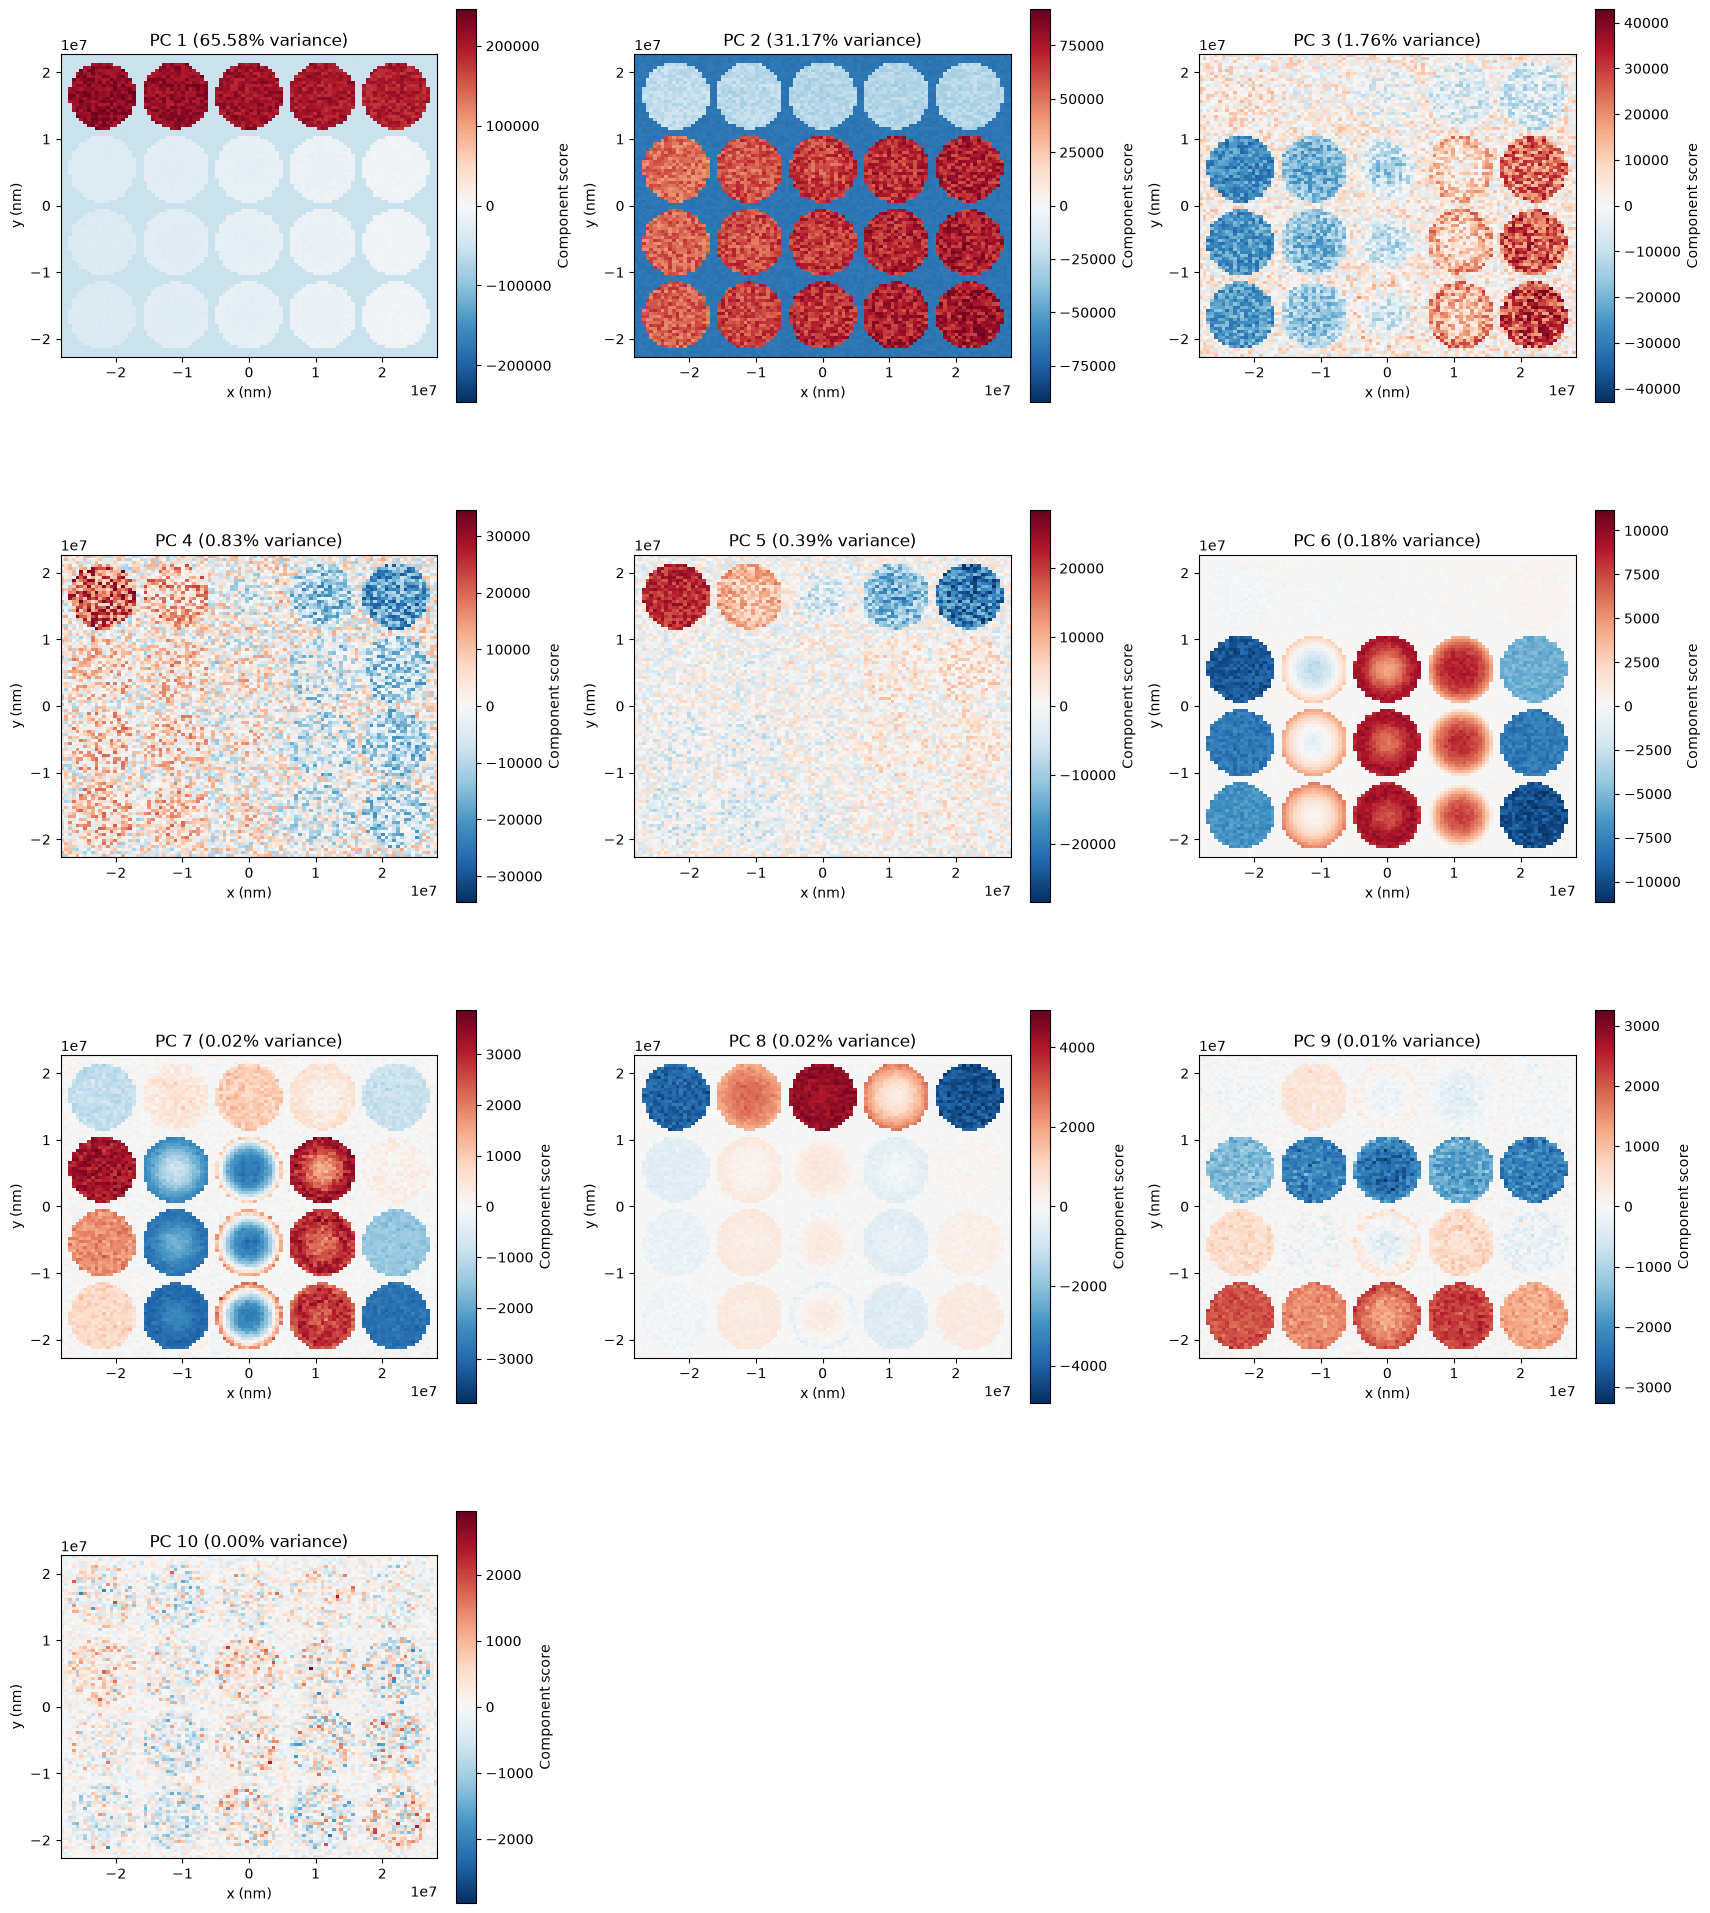

In [7]:
x_nm, y_nm = coordinates_nm.T
x_values = np.unique(x_nm)
y_values = np.unique(y_nm)
x_indices = np.searchsorted(x_values, x_nm)
y_indices = np.searchsorted(y_values, y_nm)

# Cell edges preserve physical spacing, including an irregular coordinate grid.
def cell_edges(values):
    if len(values) == 1:
        return np.array([values[0] - 0.5, values[0] + 0.5])
    midpoints = (values[:-1] + values[1:]) / 2
    return np.r_[values[0] - (values[1] - values[0]) / 2,
                 midpoints, values[-1] + (values[-1] - values[-2]) / 2]

point_counts = np.zeros((len(y_values), len(x_values)), dtype=int)
np.add.at(point_counts, (y_indices, x_indices), 1)
n_columns = 3
n_rows = int(np.ceil(n_components / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(17, 5 * n_rows),
                         squeeze=False, constrained_layout=True)
for component, ax in enumerate(axes.flat):
    if component >= n_components:
        ax.set_visible(False)
        continue
    grid = np.zeros_like(point_counts, dtype=float)
    np.add.at(grid, (y_indices, x_indices), scores[:, component])
    grid = np.divide(grid, point_counts, out=np.full_like(grid, np.nan),
                     where=point_counts > 0)
    limit = float(np.nanmax(np.abs(grid))) or 1.0
    mesh = ax.pcolormesh(cell_edges(x_values), cell_edges(y_values),
                         np.ma.masked_invalid(grid), shading="flat",
                         cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(f"PC {component + 1} ({pca.explained_variance_ratio_[component]:.2%} variance)")
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("y (nm)")
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(mesh, ax=ax, label="Component score", shrink=0.8)
plt.show()
